#MLPRegressor

    timestamp  ESP32Cocina  ESP32Habita  ESP32Hall  ESP32Salon  ESP32Salon2  \
0  1747210969        -82.0        -72.0      -67.0       -82.0        -72.0   
1  1747210975        -80.0        -72.0      -66.0       -82.0        -72.0   
2  1747210981        -79.0        -70.0      -66.0       -81.0        -74.0   
3  1747210987        -79.0        -71.0      -66.0       -81.0        -75.0   
4  1747210993        -80.0        -72.0      -67.0       -81.0        -74.0   

      x     y     z  
0  7.94  2.40 -1.31  
1  7.96  2.38 -1.37  
2  7.95  2.40 -1.34  
3  7.96  2.38 -1.34  
4  7.92  2.39 -1.34  
Columnas: ['timestamp', 'ESP32Cocina', 'ESP32Habita', 'ESP32Hall', 'ESP32Salon', 'ESP32Salon2', 'x', 'y', 'z']


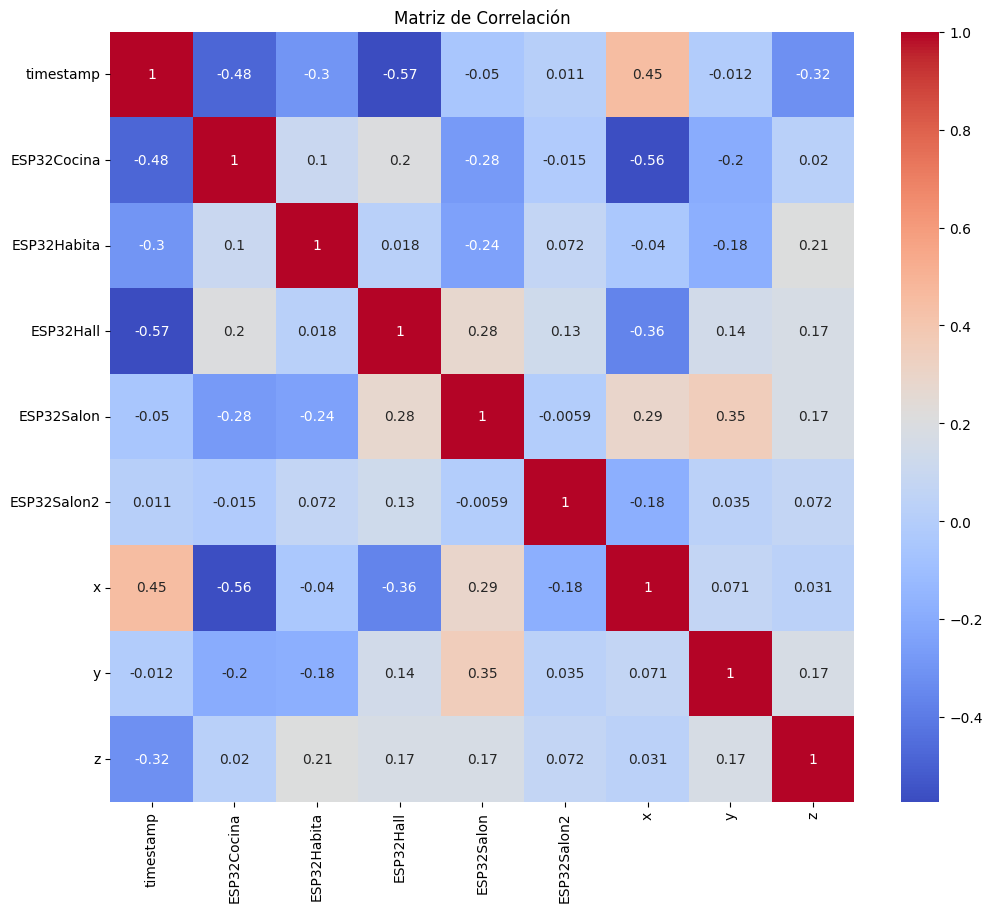

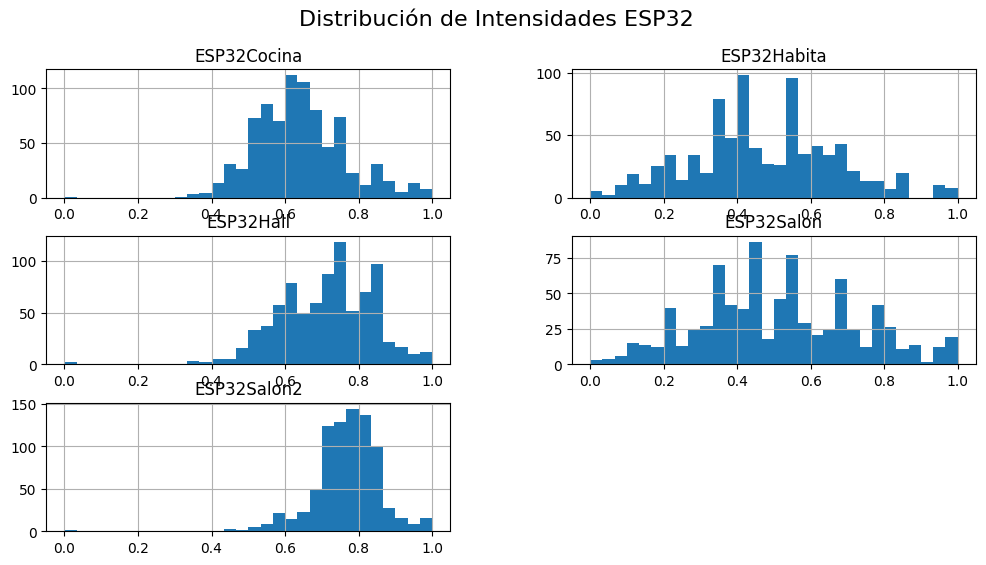

Iteration 1, loss = 0.05824992
Validation score: -0.101579
Iteration 2, loss = 0.04112910
Validation score: 0.021456
Iteration 3, loss = 0.03410276
Validation score: -0.051492
Iteration 4, loss = 0.03403685
Validation score: 0.028191
Iteration 5, loss = 0.03147910
Validation score: 0.133726
Iteration 6, loss = 0.03061595
Validation score: 0.155638
Iteration 7, loss = 0.02891968
Validation score: 0.170783
Iteration 8, loss = 0.02820197
Validation score: 0.167570
Iteration 9, loss = 0.02686081
Validation score: 0.236565
Iteration 10, loss = 0.02608877
Validation score: 0.260916
Iteration 11, loss = 0.02526989
Validation score: 0.263639
Iteration 12, loss = 0.02476881
Validation score: 0.275392
Iteration 13, loss = 0.02430833
Validation score: 0.311207
Iteration 14, loss = 0.02414260
Validation score: 0.301242
Iteration 15, loss = 0.02398507
Validation score: 0.322843
Iteration 16, loss = 0.02345841
Validation score: 0.319336
Iteration 17, loss = 0.02314678
Validation score: 0.339784
MSE 

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:698: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


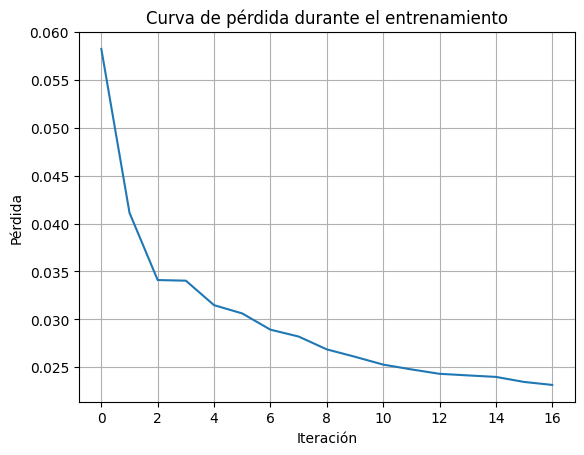

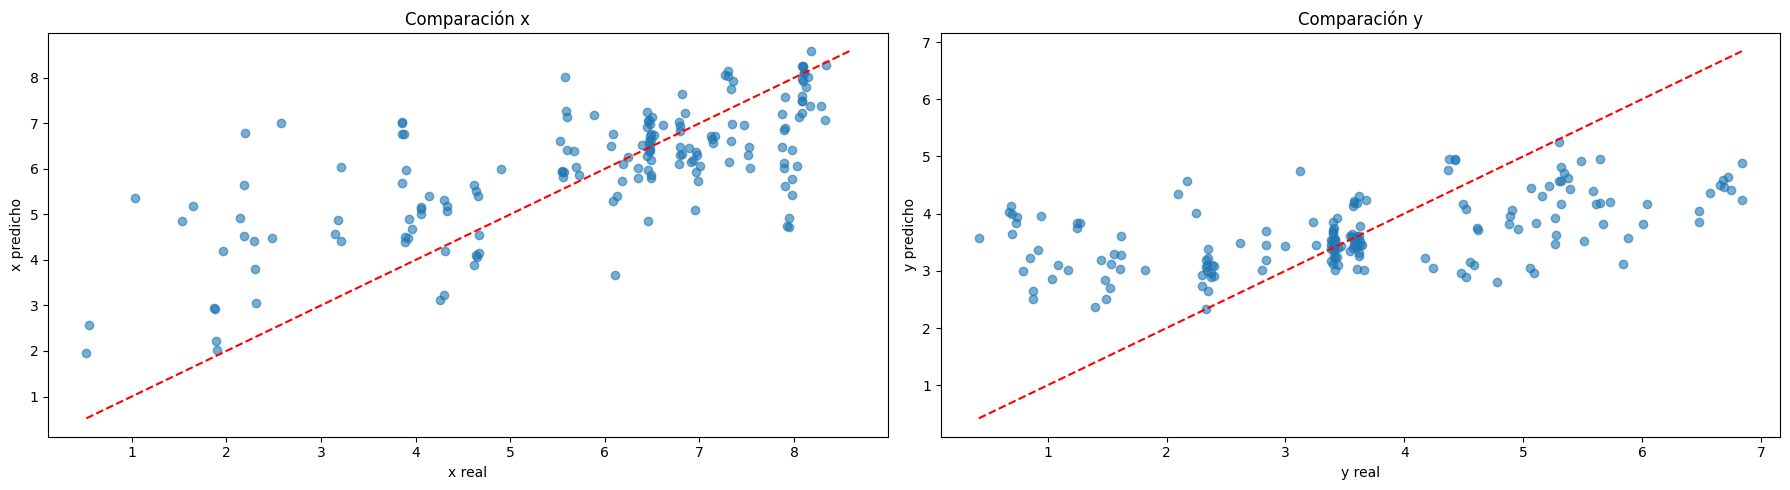

In [ ]:
#Librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import joblib

#Cargar dataset
df = pd.read_csv('BaseEntreno.csv')

#Exploración incial
print(df.head())
print("Columnas:", df.columns.tolist())

#Preprocesamiento de datos
# Agrupar por ubicación
cols_esp = ["ESP32Cocina", "ESP32Habita", "ESP32Hall", "ESP32Salon", "ESP32Salon2"]

# Convertir columnas a numéricas
df[cols_esp] = df[cols_esp].apply(pd.to_numeric, errors='coerce')
df['x'] = pd.to_numeric(df['x'], errors='coerce')
df['y'] = pd.to_numeric(df['y'], errors='coerce')

# Eliminar filas que no tengan ningún RSSI
df = df[~df[cols_esp].isna().all(axis=1)]

# Reemplazar valores faltantes con -120
df[cols_esp] = df[cols_esp].fillna(-120)

# Eliminar filas con algun null
df = df.dropna(subset=cols_esp)

# Eliminar filas sin coordenadas x o y
#df = df.dropna(subset=['x', 'y'])

# Corregir negativos
df['x'] = df['x'].clip(lower=0)
df['y'] = df['y'].clip(lower=0)

# Filtrado por cuantiles (solo si deseas limpiar extremos)
q_x_low = df['x'].quantile(0.01)
q_x_high = df['x'].quantile(0.99)
q_y_low = df['y'].quantile(0.01)
q_y_high = df['y'].quantile(0.99)

df = df[(df['x'] >= q_x_low) & (df['x'] <= q_x_high)]
df = df[(df['y'] >= q_y_low) & (df['y'] <= q_y_high)]

df.to_csv('Base1Entreno.csv', index=False)

# Normalizar todos los valores entre 0 y 1
scaler_total = MinMaxScaler()
df[cols_esp] = scaler_total.fit_transform(df[cols_esp])

# Guardar scaler_total
joblib.dump(scaler_total, 'scaler_entrada002.pkl')


# Selección de variables
scaler_y = MinMaxScaler()

X = df[cols_esp]
Y = df[['x', 'y']]

# Análisis exploratorio
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Matriz de Correlación")
plt.show()

# Histogramas
X.hist(bins=30, figsize=(12, 6))
plt.suptitle("Distribución de Intensidades ESP32", fontsize=16)
plt.show()

# Normalizar variables de salida
Y_scaled = scaler_y.fit_transform(Y)

# Crear modelo
  #Mezclar datos
X_train, X_test, y_train, y_test = train_test_split(X, Y_scaled, test_size=0.2, random_state=42)

mlp = MLPRegressor(
    hidden_layer_sizes=(256, 128, 64),  # Más capas y más neuronas
    activation='relu',
    solver='adam',
    max_iter=5000,                   # Más iteraciones permitidas
    learning_rate='adaptive',        # Ajuste del learning rate automático
    learning_rate_init=0.002,        # Tamaño inicial del paso Antes =0.001
    early_stopping=True,             # Parar si no mejora
    validation_fraction=0.1,         # Usar parte del entrenamiento como validación
    n_iter_no_change=150,            # Esperar más antes de parar por no mejorar
    alpha=0.0005,                    # Regularización L2
    random_state=42,
    verbose=True
)

# Entrenar modelo y predicciones
mlp.fit(X_train, y_train)

# Guardar el modelo entrenado
joblib.dump(mlp, 'modelo_mlp_002.pkl')
joblib.dump(scaler_y, 'scaler_salida002.pkl')

y_pred = mlp.predict(X_test)

# Evaluación del modelo

print("MSE por salida:", mean_squared_error(y_test, y_pred, multioutput='raw_values'))
print("MAE por salida", mean_absolute_error(y_test, y_pred, multioutput='raw_values'))
print("R2 por salida:", r2_score(y_test, y_pred, multioutput='raw_values'))

print("MSE promedio:", mean_squared_error(y_test, y_pred))
print("MAE promedio:", mean_absolute_error(y_test, y_pred))
print("R2 promedio:", r2_score(y_test, y_pred))

# Curva de pérdida
plt.plot(mlp.loss_curve_)
plt.title("Curva de pérdida durante el entrenamiento")
plt.xlabel("Iteración")
plt.ylabel("Pérdida")
plt.grid()
plt.show()

# Desnormalizar
y_pred_real = scaler_y.inverse_transform(y_pred)
y_test_real = scaler_y.inverse_transform(y_test)

# Comparacion predicción vs real
fig, axs = plt.subplots(1, 2, figsize=(18, 5))
for i, axis in enumerate(['x', 'y']):
    axs[i].scatter(y_test_real[:, i], y_pred_real[:, i], alpha=0.6)
    min_val = min(np.min(y_test_real[:, i]), np.min(y_pred_real[:, i]))
    max_val = max(np.max(y_test_real[:, i]), np.max(y_pred_real[:, i]))
    axs[i].plot([min_val, max_val], [min_val, max_val], 'r--')
    axs[i].set_xlabel(f'{axis} real')
    axs[i].set_ylabel(f'{axis} predicho')
    axs[i].set_title(f'Comparación {axis}')
plt.tight_layout()
plt.show()

#Modelos de Regresión


📊 Comparativa general de modelos:
LinearRegression   → MSE: [0.03783559 0.06929879] | MAE: [0.15556449 0.22115665] | R2: [0.4468169  0.24351858]
RandomForest       → MSE: [0.01707546 0.03317801] | MAE: [0.08551974 0.12331517] | R2: [0.75034468 0.63782132]
RidgeRegression    → MSE: [0.03784463 0.06931334] | MAE: [0.15563011 0.22124156] | R2: [0.44668477 0.24335975]
MLPRegressor       → MSE: [0.02277329 0.04406824] | MAE: [0.11058533 0.15633586] | R2: [0.66703845 0.51894107]


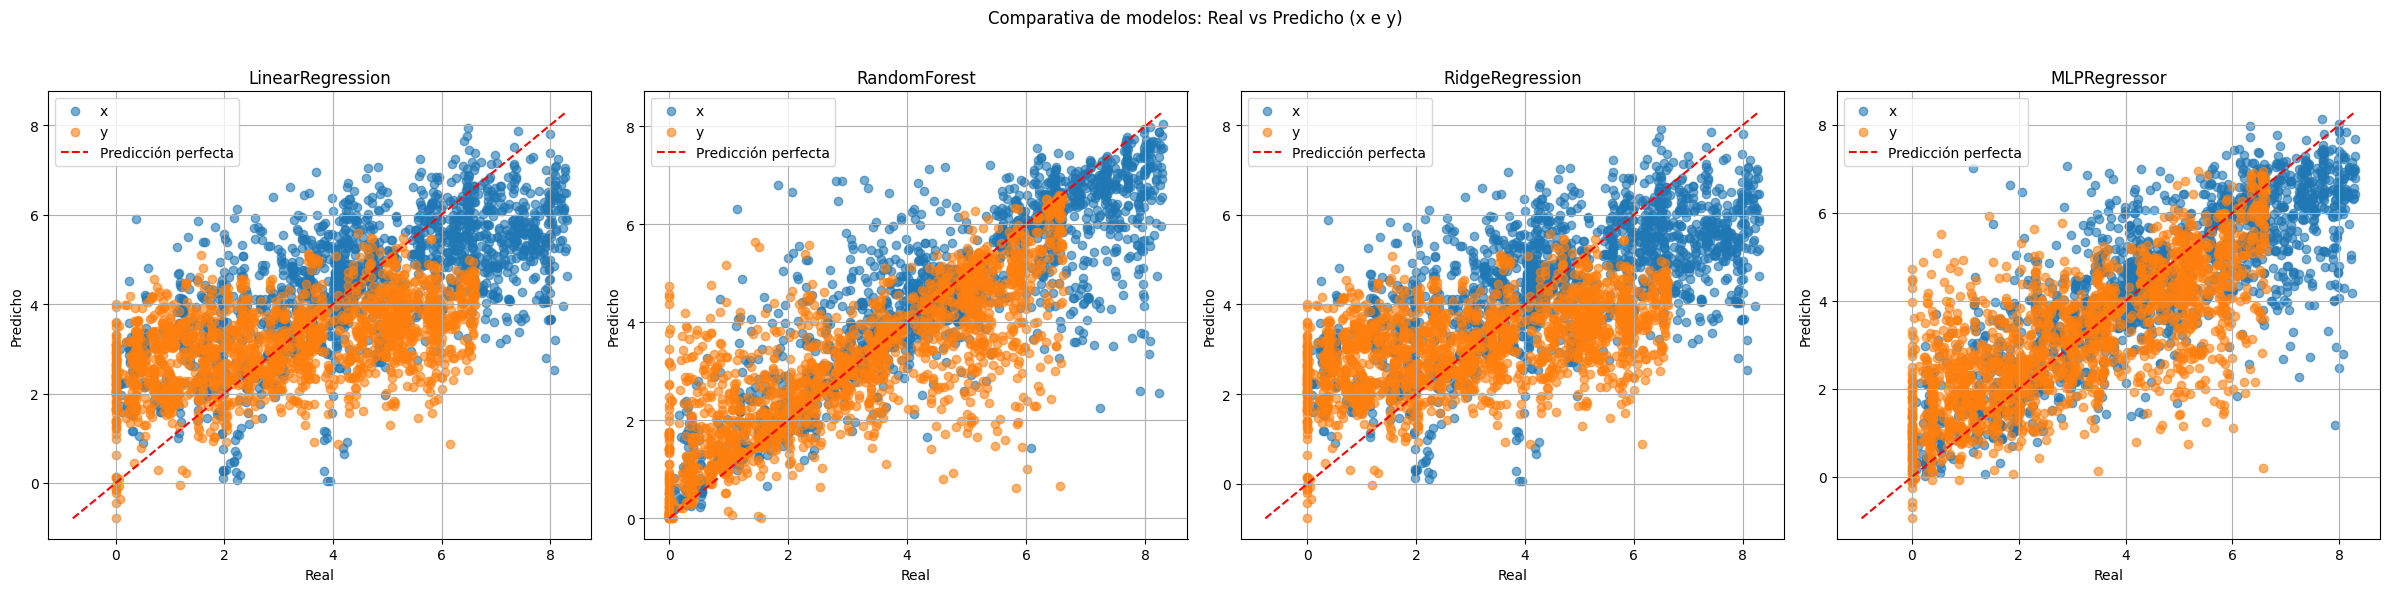

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import joblib

# Diccionario para resultados y predicciones
resultados = {}
predicciones = {}

# ================================
# Linear Regression
# ================================
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
joblib.dump(lr, 'modelo_linear.pkl')

mse_lr = mean_squared_error(y_test, y_pred_lr, multioutput='raw_values')
mae_lr = mean_absolute_error(y_test, y_pred_lr, multioutput='raw_values')
r2_lr = r2_score(y_test, y_pred_lr, multioutput='raw_values')
resultados['LinearRegression'] = (mse_lr, mae_lr, r2_lr)
predicciones['LinearRegression'] = scaler_y.inverse_transform(y_pred_lr)

# ================================
# Random Forest
# ================================
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
joblib.dump(rf, 'modelo_randomforest.pkl')

mse_rf = mean_squared_error(y_test, y_pred_rf, multioutput='raw_values')
mae_rf = mean_absolute_error(y_test, y_pred_rf, multioutput='raw_values')
r2_rf = r2_score(y_test, y_pred_rf, multioutput='raw_values')
resultados['RandomForest'] = (mse_rf, mae_rf, r2_rf)
predicciones['RandomForest'] = scaler_y.inverse_transform(y_pred_rf)

# ================================
# Ridge Regression
# ================================
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)
joblib.dump(ridge, 'modelo_ridge.pkl')

mse_ridge = mean_squared_error(y_test, y_pred_ridge, multioutput='raw_values')
mae_ridge = mean_absolute_error(y_test, y_pred_ridge, multioutput='raw_values')
r2_ridge = r2_score(y_test, y_pred_ridge, multioutput='raw_values')
resultados['RidgeRegression'] = (mse_ridge, mae_ridge, r2_ridge)
predicciones['RidgeRegression'] = scaler_y.inverse_transform(y_pred_ridge)

# ================================
# MLP
# ================================
predicciones['MLPRegressor'] = scaler_y.inverse_transform(y_pred)
resultados['MLPRegressor'] = (
    mean_squared_error(y_test, y_pred, multioutput='raw_values'),
    mean_absolute_error(y_test, y_pred, multioutput='raw_values'),
    r2_score(y_test, y_pred, multioutput='raw_values')
)

# ================================
# Mostrar resultados en consola
# ================================
print("\n📊 Comparativa general de modelos:")
for nombre, (mse, mae, r2) in resultados.items():
    print(f"{nombre:18} → MSE: {mse} | MAE: {mae} | R2: {r2}")


import matplotlib.pyplot as plt
import numpy as np

# --- Visualización de resultados para todos los modelos ---

modelos = list(predicciones.keys())
n_modelos = len(modelos)
fig, axs = plt.subplots(1, n_modelos, figsize=(6*n_modelos, 6))

if n_modelos == 1:
    axs = [axs]

for i, nombre in enumerate(modelos):
    y_pred_plot = predicciones[nombre]
    # Asegúrate de que y_test_real esté definido como tus y_test desescalados
    axs[i].scatter(y_test_real[:, 0], y_pred_plot[:, 0], alpha=0.6, label='x')
    axs[i].scatter(y_test_real[:, 1], y_pred_plot[:, 1], alpha=0.6, label='y')
    min_val = min(np.min(y_test_real), np.min(y_pred_plot))
    max_val = max(np.max(y_test_real), np.max(y_pred_plot))
    axs[i].plot([min_val, max_val], [min_val, max_val], 'r--', label='Predicción perfecta')
    axs[i].set_title(f'{nombre}')
    axs[i].set_xlabel('Real')
    axs[i].set_ylabel('Predicho')
    axs[i].legend()
    axs[i].grid(True)

plt.suptitle('Comparativa de modelos: Real vs Predicho (x e y)')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


#Modelos Clasificación


=== SVM ===
              precision    recall  f1-score   support

        Baño       0.50      0.46      0.48       259
      Cocina       0.71      0.79      0.75       303
     Entrada       0.40      0.04      0.07        55
  Habitación       0.70      0.80      0.75       426
   Ordenador       0.51      0.63      0.56       371
       Salón       0.58      0.39      0.47       338

    accuracy                           0.61      1752
   macro avg       0.57      0.52      0.51      1752
weighted avg       0.60      0.61      0.59      1752



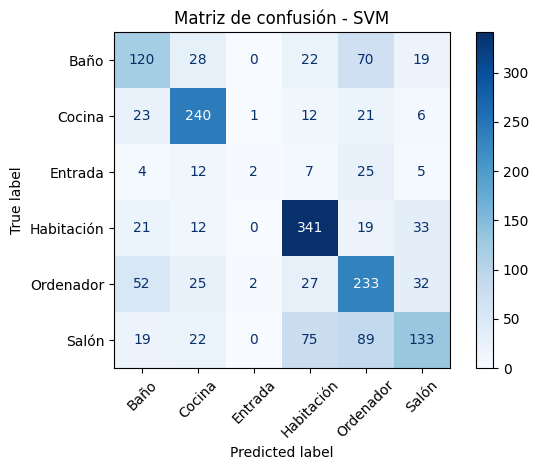


=== RandomForest ===
              precision    recall  f1-score   support

        Baño       0.69      0.73      0.71       259
      Cocina       0.83      0.89      0.86       303
     Entrada       0.54      0.35      0.42        55
  Habitación       0.80      0.84      0.82       426
   Ordenador       0.67      0.74      0.70       371
       Salón       0.79      0.63      0.70       338

    accuracy                           0.76      1752
   macro avg       0.72      0.70      0.70      1752
weighted avg       0.75      0.76      0.75      1752



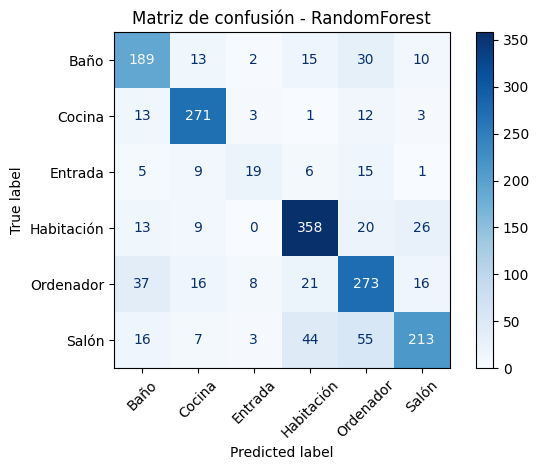


=== KNN ===
              precision    recall  f1-score   support

        Baño       0.57      0.73      0.64       259
      Cocina       0.76      0.83      0.79       303
     Entrada       0.39      0.25      0.31        55
  Habitación       0.73      0.82      0.77       426
   Ordenador       0.66      0.61      0.64       371
       Salón       0.73      0.52      0.61       338

    accuracy                           0.69      1752
   macro avg       0.64      0.63      0.63      1752
weighted avg       0.69      0.69      0.68      1752



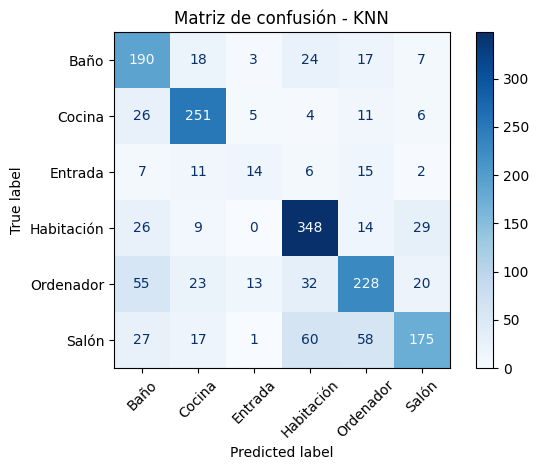


=== DecisionTree ===
              precision    recall  f1-score   support

        Baño       0.57      0.70      0.63       259
      Cocina       0.78      0.77      0.78       303
     Entrada       0.32      0.40      0.36        55
  Habitación       0.78      0.74      0.76       426
   Ordenador       0.65      0.59      0.62       371
       Salón       0.67      0.64      0.65       338

    accuracy                           0.68      1752
   macro avg       0.63      0.64      0.63      1752
weighted avg       0.68      0.68      0.68      1752



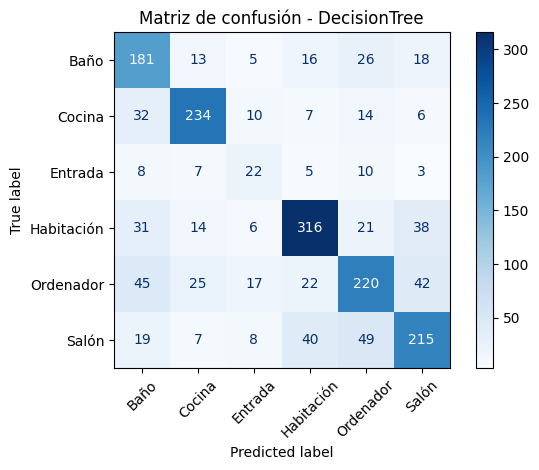

In [ ]:
# Librerías
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Cargar y preprocesar
df = pd.read_csv('LocationEntrenamientoDef.csv')

cols_esp = ["ESP32Cocina", "ESP32Habita", "ESP32Hall", "ESP32Salon", "ESP32Salon2"]
df[cols_esp] = df[cols_esp].apply(pd.to_numeric, errors='coerce')
df['x'] = pd.to_numeric(df['x'], errors='coerce')
df['y'] = pd.to_numeric(df['y'], errors='coerce')
df = df[~df[cols_esp].isna().all(axis=1)]
df = df.dropna(subset=cols_esp + ['x', 'y'])

# Clasificación por habitación según coordenadas
def asignar_habitacion(x, y):
    zonas = [
        ('Entrada',     0, 2.65, 4.5, 6.8),
        ('Ordenador',   2.65, 4.85, 3.55, 6.8),
        ('Salón',       4.85, 8.38, 3.55, 6.8),
        ('Cocina',      0, 2.65, 0, 4.5),
        ('Baño',        2.65, 5.18, 0, 3.55),
        ('Habitación',  5.18, 8.38, 0, 3.55)
    ]
    for nombre, xMin, xMax, yMin, yMax in zonas:
        if xMin <= x <= xMax and yMin <= y <= yMax:
            return nombre
    return 'Desconocido'

df['habitacion'] = df.apply(lambda row: asignar_habitacion(row['x'], row['y']), axis=1)
df = df[df['habitacion'] != 'Desconocido']

# Normalización de entradas
scaler = MinMaxScaler()
X = scaler.fit_transform(df[cols_esp])
joblib.dump(scaler, 'scaler_clasificacion.pkl')

# Codificación de etiquetas
le = LabelEncoder()
y = le.fit_transform(df['habitacion'])
joblib.dump(le, 'label_encoder.pkl')

# División
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Clasificadores a evaluar
modelos = {
    "SVM": SVC(kernel='rbf', probability=True),
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "DecisionTree": DecisionTreeClassifier(random_state=42)
}

# Entrenamiento y evaluación
for nombre, modelo in modelos.items():
    print(f"\n=== {nombre} ===")
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)

    # Guardar modelo
    joblib.dump(modelo, f'modelo_clasificador_{nombre}.pkl')

    # Reporte
    print(classification_report(y_test, y_pred, target_names=le.classes_))

    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(cmap="Blues", xticks_rotation=45)
    plt.title(f"Matriz de confusión - {nombre}")
    plt.tight_layout()
    plt.show()


#Experimentación

In [ ]:
#Librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import joblib

#Cargar dataset
df = pd.read_csv('LocationEntrenamientoDef.csv')

#Exploración incial
print(df.head())
print("Columnas:", df.columns.tolist())

#Preprocesamiento de datos
# Convertir todos los datos a numéricos
df = df.apply(pd.to_numeric, errors='coerce')

# Definir columnas
todos_esp = [col for col in df.columns if col.startswith("ESP32")]
esp_objetivo =  ''
esp_modificar = [col for col in todos_esp if col not in esp_objetivo]

# Forzar todos los valores a -120 en los ESP32 que no son el objetivo
df[esp_modificar] = -120

# Eliminar filas con NaN en los ESP32 reales
if esp_Objetivo != ''
  df = df.dropna(subset=esp_objetivo)

# Eliminar filas sin coordenadas (opcional si las quieres limpiar)
df = df.dropna(subset=['x', 'y'])

# Corregir negativos en coordenadas
df['x'] = df['x'].clip(lower=0)
df['y'] = df['y'].clip(lower=0)

# Eliminar filas sin coordenadas x o y
#df = df.dropna(subset=['x', 'y'])

# Corregir negativos
df['x'] = df['x'].clip(lower=0)
df['y'] = df['y'].clip(lower=0)

# Filtrado por cuantiles (solo si deseas limpiar extremos)
q_x_low = df['x'].quantile(0.01)
q_x_high = df['x'].quantile(0.99)
q_y_low = df['y'].quantile(0.01)
q_y_high = df['y'].quantile(0.99)

df = df[(df['x'] >= q_x_low) & (df['x'] <= q_x_high)]
df = df[(df['y'] >= q_y_low) & (df['y'] <= q_y_high)]

df.to_csv('Base1Entreno.csv', index=False)

# Normalizar todos los valores entre 0 y 1
scaler_total = MinMaxScaler()
df[cols_esp] = scaler_total.fit_transform(df[todos_esp])

# Guardar scaler_total
joblib.dump(scaler_total, 'scaler_entrada002.pkl')


# Selección de variables
scaler_y = MinMaxScaler()

X = df[todos_esp]
Y = df[['x', 'y']]

# Análisis exploratorio
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Matriz de Correlación")
plt.show()

# Histogramas
X.hist(bins=30, figsize=(12, 6))
plt.suptitle("Distribución de Intensidades ESP32", fontsize=16)
plt.show()

# Normalizar variables de salida
Y_scaled = scaler_y.fit_transform(Y)

# Crear modelo
  #Mezclar datos
X_train, X_test, y_train, y_test = train_test_split(X, Y_scaled, test_size=0.2, random_state=42)

mlp = MLPRegressor(
    hidden_layer_sizes=(256, 128, 64),  # Más capas y más neuronas
    activation='relu',
    solver='adam',
    max_iter=5000,                   # Más iteraciones permitidas
    learning_rate='adaptive',        # Ajuste del learning rate automático
    learning_rate_init=0.002,        # Tamaño inicial del paso Antes =0.001
    early_stopping=True,             # Parar si no mejora
    validation_fraction=0.1,         # Usar parte del entrenamiento como validación
    n_iter_no_change=150,            # Esperar más antes de parar por no mejorar
    alpha=0.0005,                    # Regularización L2
    random_state=42,
    verbose=True
)

# Entrenar modelo y predicciones
mlp.fit(X_train, y_train)

# Guardar el modelo entrenado
joblib.dump(mlp, 'modelo_mlp_002.pkl')
joblib.dump(scaler_y, 'scaler_salida002.pkl')

y_pred = mlp.predict(X_test)

# Evaluación del modelo

print("MSE por salida:", mean_squared_error(y_test, y_pred, multioutput='raw_values'))
print("MAE por salida", mean_absolute_error(y_test, y_pred, multioutput='raw_values'))
print("R2 por salida:", r2_score(y_test, y_pred, multioutput='raw_values'))

print("MSE promedio:", mean_squared_error(y_test, y_pred))
print("MAE promedio:", mean_absolute_error(y_test, y_pred))
print("R2 promedio:", r2_score(y_test, y_pred))

# Curva de pérdida
plt.plot(mlp.loss_curve_)
plt.title("Curva de pérdida durante el entrenamiento")
plt.xlabel("Iteración")
plt.ylabel("Pérdida")
plt.grid()
plt.show()

# Desnormalizar
y_pred_real = scaler_y.inverse_transform(y_pred)
y_test_real = scaler_y.inverse_transform(y_test)

# Comparacion predicción vs real
fig, axs = plt.subplots(1, 2, figsize=(18, 5))
for i, axis in enumerate(['x', 'y']):
    axs[i].scatter(y_test_real[:, i], y_pred_real[:, i], alpha=0.6)
    min_val = min(np.min(y_test_real[:, i]), np.min(y_pred_real[:, i]))
    max_val = max(np.max(y_test_real[:, i]), np.max(y_pred_real[:, i]))
    axs[i].plot([min_val, max_val], [min_val, max_val], 'r--')
    axs[i].set_xlabel(f'{axis} real')
    axs[i].set_ylabel(f'{axis} predicho')
    axs[i].set_title(f'Comparación {axis}')
plt.tight_layout()
plt.show()

    timestamp ESP32Cocina ESP32Habita ESP32Hall ESP32Salon ESP32Salon2     x  \
0  1747210969         -82         -72       -67        -82         -72  7.94   
1  1747210975         -80         -72       -66        -82         -72  7.96   
2  1747210981         -79         -70       -66        -81         -74  7.95   
3  1747210987         -79         -71       -66        -81         -75  7.96   
4  1747210993         -80         -72       -67        -81         -74  7.92   

      y      z  
0   2.4  -1.31  
1  2.38  -1.37  
2   2.4  -1.34  
3  2.38  -1.34  
4  2.39  -1.34  
Columnas: ['timestamp', 'ESP32Cocina', 'ESP32Habita', 'ESP32Hall', 'ESP32Salon', 'ESP32Salon2', 'x', 'y', 'z']


KeyError: ['']


📊 Comparativa general de modelos:
LinearRegression   → MSE: [0.04644747 0.08302512] | MAE: [0.17710135 0.24989906] | R2: [0.31359087 0.07299758]
RandomForest       → MSE: [0.04417595 0.0807473 ] | MAE: [0.17216428 0.2441645 ] | R2: [0.34715977 0.09843024]
RidgeRegression    → MSE: [0.0464602  0.08303349] | MAE: [0.17715972 0.24994762] | R2: [0.31340269 0.07290418]
MLPRegressor       → MSE: [0.04441937 0.0816284 ] | MAE: [0.17282134 0.24648467] | R2: [0.34356247 0.08859242]


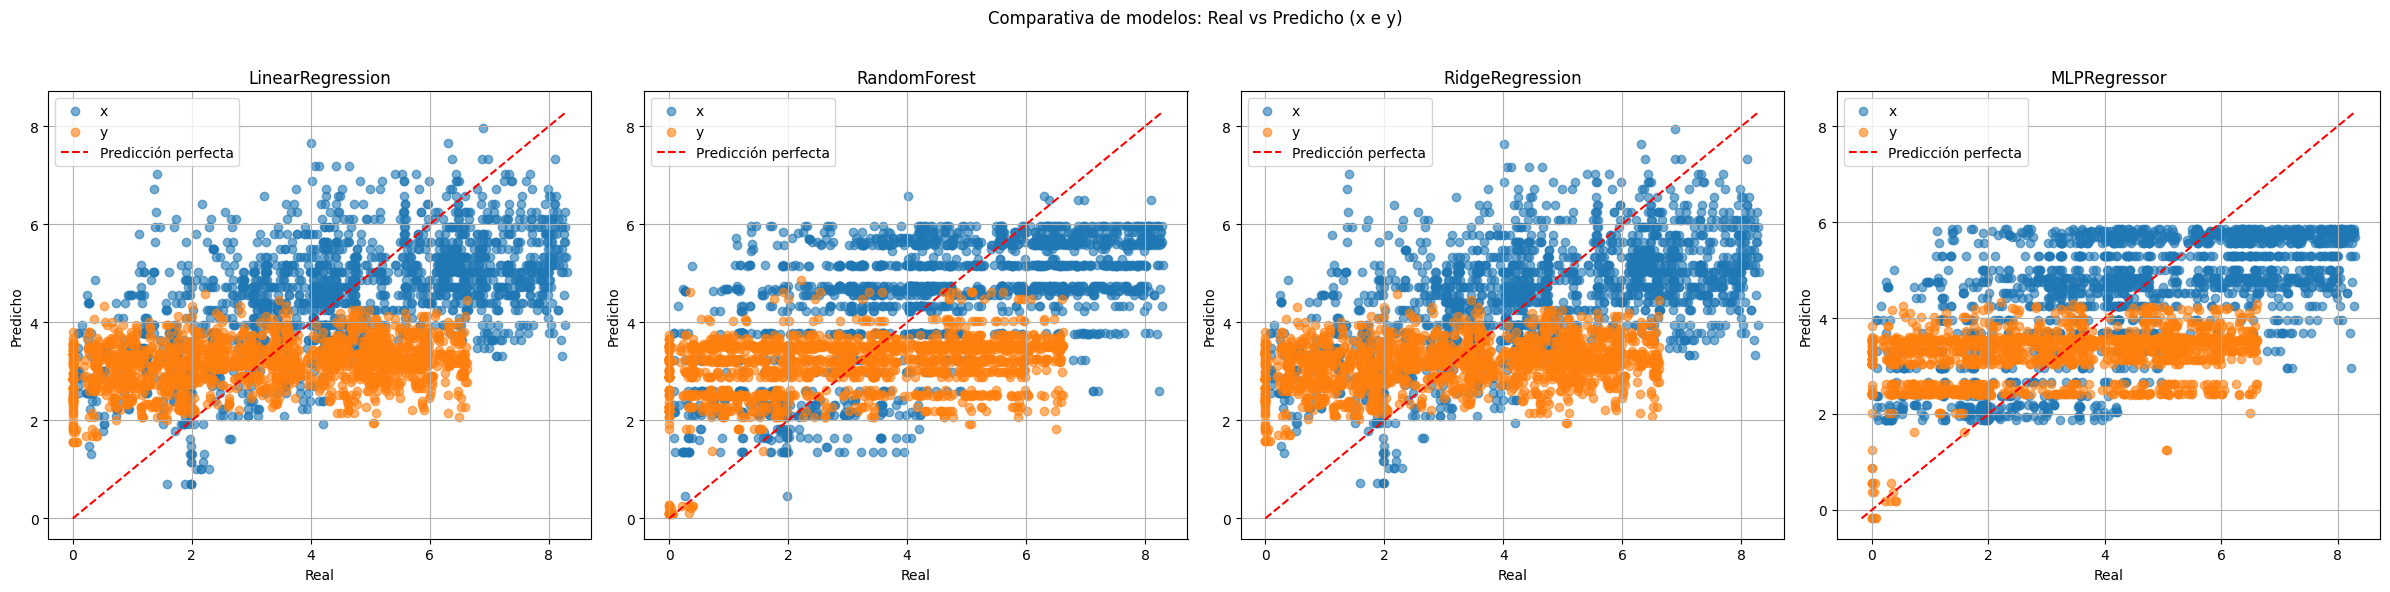

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import joblib

# Diccionario para resultados y predicciones
resultados = {}
predicciones = {}

# ================================
# Linear Regression
# ================================
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
joblib.dump(lr, 'modelo_linear.pkl')

mse_lr = mean_squared_error(y_test, y_pred_lr, multioutput='raw_values')
mae_lr = mean_absolute_error(y_test, y_pred_lr, multioutput='raw_values')
r2_lr = r2_score(y_test, y_pred_lr, multioutput='raw_values')
resultados['LinearRegression'] = (mse_lr, mae_lr, r2_lr)
predicciones['LinearRegression'] = scaler_y.inverse_transform(y_pred_lr)

# ================================
# Random Forest
# ================================
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
joblib.dump(rf, 'modelo_randomforest.pkl')

mse_rf = mean_squared_error(y_test, y_pred_rf, multioutput='raw_values')
mae_rf = mean_absolute_error(y_test, y_pred_rf, multioutput='raw_values')
r2_rf = r2_score(y_test, y_pred_rf, multioutput='raw_values')
resultados['RandomForest'] = (mse_rf, mae_rf, r2_rf)
predicciones['RandomForest'] = scaler_y.inverse_transform(y_pred_rf)

# ================================
# Ridge Regression
# ================================
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)
joblib.dump(ridge, 'modelo_ridge.pkl')

mse_ridge = mean_squared_error(y_test, y_pred_ridge, multioutput='raw_values')
mae_ridge = mean_absolute_error(y_test, y_pred_ridge, multioutput='raw_values')
r2_ridge = r2_score(y_test, y_pred_ridge, multioutput='raw_values')
resultados['RidgeRegression'] = (mse_ridge, mae_ridge, r2_ridge)
predicciones['RidgeRegression'] = scaler_y.inverse_transform(y_pred_ridge)

# ================================
# MLP
# ================================
predicciones['MLPRegressor'] = scaler_y.inverse_transform(y_pred)
resultados['MLPRegressor'] = (
    mean_squared_error(y_test, y_pred, multioutput='raw_values'),
    mean_absolute_error(y_test, y_pred, multioutput='raw_values'),
    r2_score(y_test, y_pred, multioutput='raw_values')
)

# ================================
# Mostrar resultados en consola
# ================================
print("\n📊 Comparativa general de modelos:")
for nombre, (mse, mae, r2) in resultados.items():
    print(f"{nombre:18} → MSE: {mse} | MAE: {mae} | R2: {r2}")


import matplotlib.pyplot as plt
import numpy as np

# --- Visualización de resultados para todos los modelos ---

modelos = list(predicciones.keys())
n_modelos = len(modelos)
fig, axs = plt.subplots(1, n_modelos, figsize=(6*n_modelos, 6))

if n_modelos == 1:
    axs = [axs]

for i, nombre in enumerate(modelos):
    y_pred_plot = predicciones[nombre]
    # Asegúrate de que y_test_real esté definido como tus y_test desescalados
    axs[i].scatter(y_test_real[:, 0], y_pred_plot[:, 0], alpha=0.6, label='x')
    axs[i].scatter(y_test_real[:, 1], y_pred_plot[:, 1], alpha=0.6, label='y')
    min_val = min(np.min(y_test_real), np.min(y_pred_plot))
    max_val = max(np.max(y_test_real), np.max(y_pred_plot))
    axs[i].plot([min_val, max_val], [min_val, max_val], 'r--', label='Predicción perfecta')
    axs[i].set_title(f'{nombre}')
    axs[i].set_xlabel('Real')
    axs[i].set_ylabel('Predicho')
    axs[i].legend()
    axs[i].grid(True)

plt.suptitle('Comparativa de modelos: Real vs Predicho (x e y)')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
